In [10]:
pip install pandas numpy yfinance plotly scikit-learn ta streamlit

  Using cached ta-0.11.0-py3-none-any.whl
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------- ----------------------- 4.2/9.9 MB 23.4 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 25.7 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 18.3 MB/s  0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------------------- -------- 6.3/8.0 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 20.3 MB/s  0:00:00
   ------------------

  You can safely remove it manually.


# AI Stock Analysis Exploration
# This notebook explores financial data and technical indicators
# used in the AI Stock Dashboard.

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
data = yf.download("AAPL", period="5y")

data.columns = data.columns.get_level_values(0)

data.head()



[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-03-17,121.515678,122.587072,119.158604,120.824143,111932600
2021-03-18,117.395676,119.976765,117.191137,119.684564,121229700
2021-03-19,116.869713,118.272269,116.567777,116.782057,185549500
2021-03-22,120.181305,120.648826,117.132702,117.200881,111912300
2021-03-23,119.353432,121.009221,118.963832,120.122889,95467100


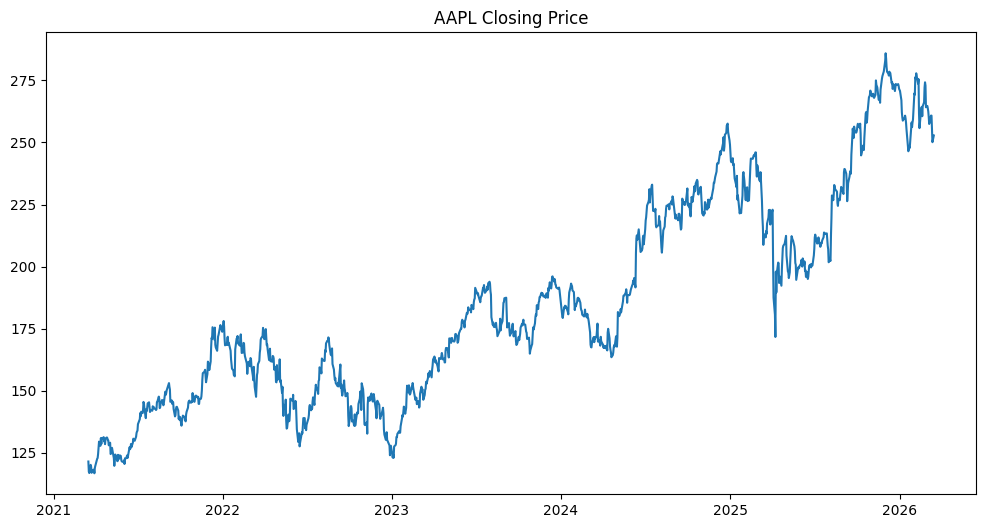

In [6]:
plt.figure(figsize=(12,6))
plt.plot(data["Close"])
plt.title("AAPL Closing Price")
plt.show()

In [17]:
from ta.momentum import RSIIndicator
from ta.trend import MACD

# Ensure Close column is numeric
data["Close"] = pd.to_numeric(data["Close"], errors="coerce")

# Drop NaNs
data = data.dropna()

# RSI
rsi = RSIIndicator(close=data["Close"].squeeze(), window=14)
data["RSI"] = rsi.rsi()

# MACD
macd = MACD(close=data["Close"].squeeze())
data["MACD"] = macd.macd()
data["MACD_SIGNAL"] = macd.macd_signal()

data.tail()

Price,Close,High,Low,Open,Volume,RSI,MACD,MACD_SIGNAL
Date,,,,,,,,
2026-03-10,260.829987,262.480011,256.950012,257.649994,30590800,45.489524,-1.262219,-0.266457
2026-03-11,260.809998,262.130005,259.549988,261.089996,26218900,45.465651,-1.340312,-0.481228
2026-03-12,255.759995,258.950012,254.179993,258.660004,40794000,39.785106,-1.789072,-0.742797
2026-03-13,250.119995,256.329987,249.520004,255.479996,36889900,34.587558,-2.570190,-1.108276
2026-03-16,252.820007,253.884995,249.880005,252.104996,30091880,38.715201,-2.937502,-1.474121


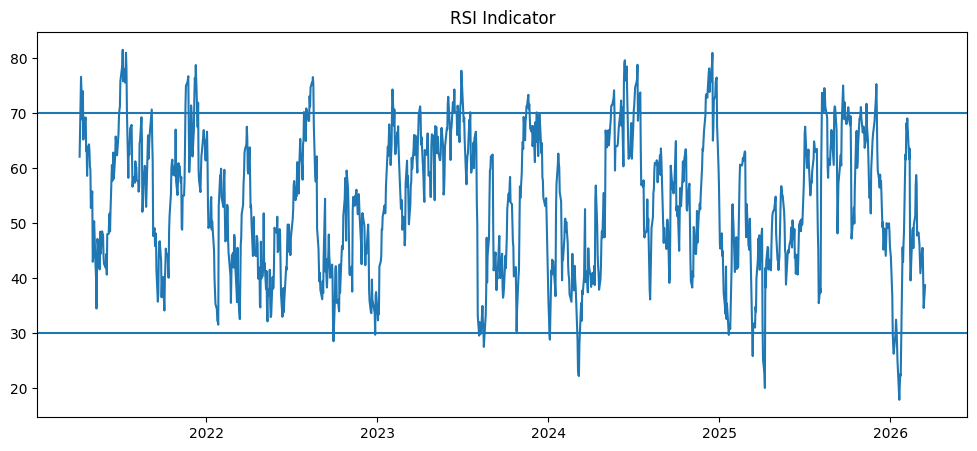

In [18]:
plt.figure(figsize=(12,5))
plt.plot(data["RSI"])
plt.axhline(70)
plt.axhline(30)
plt.title("RSI Indicator")
plt.show()

In [19]:
from sklearn.ensemble import RandomForestRegressor

data["Target"] = data["Close"].shift(-7)

data = data.dropna()

X = data[["RSI","MACD"]]
y = data["Target"]

model = RandomForestRegressor()
model.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
prediction = model.predict(X.iloc[-1:])
print(prediction)

[243.61102219]
